# Redes neuronales para la clasificación de emociones

Curso: Minería de Datos

Proyecto: Clasificación automática de emociones en publicaciones de jóvenes peruanos

### 1. Preparación del entorno

#### Verificar la GPU

Utilizaremos Google Colab para aprovechar su GPU y que el proceso sea mucho más rápido.

In [1]:
import torch
import sys

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo detectado: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("[!] NO se detectó GPU. El entrenamiento será muy lento.")

Dispositivo detectado: cuda
GPU: Tesla T4
Memoria: 15.6 GB


#### Entorno de ejecución

In [2]:
import os
import sys

# Detección del entorno de ejecución
if os.path.exists('/content'):
    print("Entorno Nube (Colab) Detectado.")
    print("Montando Google Drive...")
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception as e:
        print("Error al montar Drive:", e)
    
    BASE_DIR = '/content'
    DATOS_DIR = '/content/drive/MyDrive/Proyecto-Mineria-G4/prueba'
else:
    print("Entorno Local Detectado.")
    try:
        current_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        current_dir = os.getcwd()

    BASE_DIR = current_dir
    while BASE_DIR != os.path.dirname(BASE_DIR):
        if 'modelado' in os.listdir(BASE_DIR) and os.path.isdir(os.path.join(BASE_DIR, 'modelado')):
            break
        BASE_DIR = os.path.dirname(BASE_DIR)
        
    DATOS_DIR = os.path.join(BASE_DIR, 'modelado', 'datos')

if BASE_DIR not in sys.path:
    sys.path.append(BASE_DIR)

RESULTADOS_DIR = os.path.join(BASE_DIR, 'resultados_nn' if '/content' in BASE_DIR else 'modelado/resultados_nn')
os.makedirs(RESULTADOS_DIR, exist_ok=True)

print(f"Directorio de datos: {DATOS_DIR}")
print(f"Directorio de resultados: {RESULTADOS_DIR}")


Mounted at /content/drive
Directorio de datos: /content/drive/MyDrive/Proyecto-Mineria-G4/prueba
Directorio de resultados: /content/resultados_nn


#### Importación de librerías

In [10]:
import glob
import collections
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo de procesamiento detectado: {device}")

Dispositivo de procesamiento detectado: cuda


#### Hiperparámetros de la Red Neuronal


In [11]:
# Valores
MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 64
BATCH_SIZE = 32
EPOCHS = 10
PATIENCE = 3 # Early stopping tolerance
LEARNING_RATE = 0.001

### 2. Carga y estandarización de los datasets

Se cargan los 3 datasets preprocesados (YouTube parte 1, YouTube parte 2, TikTok) y se unifican en un solo dataframe.

In [12]:
archivos = [
    os.path.join(DATOS_DIR, 'dataset_procesado_tiktok_parte01.csv'),
    os.path.join(DATOS_DIR, 'dataset_procesado_youtube_parte01.csv'),
    os.path.join(DATOS_DIR, 'dataset_procesado_youtube_parte02.csv')
]

dfs = []
for f in archivos:
    if os.path.exists(f):
        print(f"Cargando {os.path.basename(f)}...")
        temp_df = pd.read_csv(f, sep=';', encoding='utf-8')
        temp_df.columns = temp_df.columns.str.strip().str.replace('"', '').str.lower()
        dfs.append(temp_df)

if not dfs:
    raise ValueError(f"No se encontraron datasets en la ruta: {DATOS_DIR}")

df = pd.concat(dfs, ignore_index=True)
df['emocion'] = df['emocion'].astype(str).str.strip().str.replace('"', '').str.capitalize()
df['emocion'] = df['emocion'].replace({'Alegría': 'Alegria'})

# Filtro de las emociones
emociones_validas = ['Sorpresa', 'Miedo', 'Alegria', 'Tristeza']
df = df[df['emocion'].isin(emociones_validas)]
df = df.dropna(subset=['lemas', 'emocion'])

print(f"\nTotal de registros consolidados: {len(df)}")
print(f"Distribución de clases:\n{df['emocion'].value_counts()}")


Cargando dataset_procesado_tiktok_parte01.csv...
Cargando dataset_procesado_youtube_parte01.csv...
Cargando dataset_procesado_youtube_parte02.csv...

Total de registros consolidados: 9065
Distribución de clases:
emocion
Tristeza    2684
Alegria     2329
Sorpresa    2048
Miedo       2004
Name: count, dtype: int64


### 3. Preparación de tensores


In [13]:
le = LabelEncoder()
y = le.fit_transform(df['emocion'])
texts = df['lemas'].astype(str).tolist()
def build_vocab(texts, max_words=MAX_WORDS):
    words = []
    for text in texts:
        words.extend(str(text).split())
    counter = collections.Counter(words)
    vocab = {word: idx + 2 for idx, (word, _) in enumerate(counter.most_common(max_words - 2))}
    return vocab
def texts_to_sequences(texts, vocab):
    seqs = []
    for text in texts:
        seq = [vocab.get(w, 1) for w in str(text).split()]
        seqs.append(seq)
    return seqs
def pad_sequences(seqs, maxlen=MAX_LEN):
    padded = np.zeros((len(seqs), maxlen), dtype=int)
    for i, seq in enumerate(seqs):
        if len(seq) > maxlen:
            padded[i, :] = seq[:maxlen]
        else:
            padded[i, -len(seq):] = seq
    return padded
vocab = build_vocab(texts)
vocab_size = min(MAX_WORDS, len(vocab) + 2)
seqs = texts_to_sequences(texts, vocab)
X = pad_sequences(seqs)

# División de datos: 80% entrenamiento / 20% prueba
# Luego, del 80%: 70% entrenamiento efectivo / 30% validación
total = len(y)
print(f'Total de registros (4 emociones): {total}')
# 1er corte: separar el 20% de prueba
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# 2do corte: del 80% restante, 30% para validación (= ~24% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.30, random_state=42, stratify=y_temp
)
print(f'Entrenamiento Efectivo: {len(X_train)} registros (~{len(X_train)/total*100:.1f}%)')
print(f'Validación:             {len(X_val)} registros (~{len(X_val)/total*100:.1f}%)')
print(f'Prueba y Evaluación:    {len(X_test)} registros (~{len(X_test)/total*100:.1f}%)')
X_train_t = torch.tensor(X_train, dtype=torch.long)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t   = torch.tensor(X_val,   dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
X_test_t  = torch.tensor(X_test,  dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
num_classes = len(le.classes_)
print(f"Clases identificadas ({num_classes}): {le.classes_}")

Total de registros (4 emociones): 9065
Entrenamiento Efectivo: 5076 registros (~56.0%)
Validación:             2176 registros (~24.0%)
Prueba y Evaluación:    1813 registros (~20.0%)
Clases identificadas (4): ['Alegria' 'Miedo' 'Sorpresa' 'Tristeza']


### 4. Definición de modelos de deep learning (CNN y LSTM)


In [14]:
# CNN 1D
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv = nn.Conv1d(in_channels=embed_dim, out_channels=128, kernel_size=5)
        self.relu = nn.ReLU()
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x) 
        x = x.permute(0, 2, 1) 
        x = self.conv(x)
        x = self.relu(x)
        x = torch.max(x, dim=2)[0] 
        out = self.fc(x)
        return out

# LSTM
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, 64, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        out, (hn, cn) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

print("Modelos listos.")

Modelos listos.


#### Función de entrenamiento de los modelos


In [15]:
def train_model(model, train_loader, val_loader, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    best_loss = float('inf')
    patience_counter = 0
    
    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
                
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        print(f"   Época {epoch+1}/{EPOCHS} - Perdida Train: {train_loss:.4f} - Perdida Val: {val_loss:.4f}")
        
        # Early Stopping
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("   [!] Early stopping ejecutado.")
                break
    return model

print("Función generica de entrenamiento de los modelos listo.")

Función generica de entrenamiento de los modelos listo.


#### Función de evaluación de los modelos con las métricas

In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_and_plot(model, nombre_modelo, dataloader, device, le, archivo_reporte, titulo_seccion=None):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs = F.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='macro', zero_division=0) # Sensibilidad
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    print(f"\n Resultados para {nombre_modelo}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (macro): {prec:.4f}")
    print(f"Sensibilidad/Recall (macro): {rec:.4f}")
    print(f"F1-Score (macro): {f1:.4f}")
            
    print(f"\nReporte de Clasificación:")
    y_test_labels = le.inverse_transform(all_labels)
    y_pred_labels = le.inverse_transform(all_preds)
    reporte_str = classification_report(y_test_labels, y_pred_labels, labels=le.classes_, zero_division=0)
    print(reporte_str)
    
    # 1. Matriz de Confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Matriz de Confusión - {nombre_modelo}')
    plt.xlabel('Predicción')
    plt.ylabel('Real')
    plt.tight_layout()
    ruta_cm = os.path.join(RESULTADOS_DIR, f'cm_{nombre_modelo}.png')
    plt.savefig(ruta_cm)
    plt.show()
    
    # 2. Curva ROC / AUC (One-vs-Rest)
    y_test_bin = label_binarize(all_labels, classes=range(len(le.classes_)))
    n_classes = len(le.classes_)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes

    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])
    
    plt.figure(figsize=(7, 6))
    plt.plot(fpr["macro"], tpr["macro"],
             label=f'Macro-average ROC (area = {roc_auc["macro"]:.2f})',
             color='navy', linestyle=':', linewidth=4)
             
    colors = ['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple']
    for i, color in zip(range(n_classes), colors):
        c = color if i < len(colors) else 'black'
        plt.plot(fpr[i], tpr[i], color=c, lw=2,
                 label=f'ROC {le.classes_[i]} (area = {roc_auc[i]:.2f})')
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
    plt.title(f'Curva ROC Multiclase (OvR) - {nombre_modelo}')
    plt.legend(loc="lower right", fontsize=8)
    ruta_roc = os.path.join(RESULTADOS_DIR, f'roc_{nombre_modelo}.png')
    plt.savefig(ruta_roc)
    plt.show()
    
    # Escribir resultados en el archivo markdown
    with open(archivo_reporte, 'a', encoding='utf-8') as f:
        encabezado = titulo_seccion if titulo_seccion else nombre_modelo
        f.write(f"### {encabezado}\n\n") 
        f.write(f"#### {nombre_modelo}\n\n")
        f.write(f"- **Accuracy:** {acc:.4f}\n")
        f.write(f"- **Precision (macro):** {prec:.4f}\n")
        f.write(f"- **Sensibilidad/Recall (macro):** {rec:.4f}\n")
        f.write(f"- **F1-Score (macro):** {f1:.4f}\n\n")
        
        f.write("```text\n")
        f.write(reporte_str)
        f.write("\n```\n\n")
        
        f.write(f"**Matriz de Confusión:**\n\n![Matriz de Confusión {nombre_modelo}](./cm_{nombre_modelo}.png)\n\n")
        
        f.write(f"**Curva ROC / AUC:**\n\n![Curva ROC {nombre_modelo}](./roc_{nombre_modelo}.png)\n\n")

print("Función generica de evaluación de los modelos y exportación de los resultados listo.")

Función generica de evaluación de los modelos y exportación de los resultados listo.


### 5. Ejecución del pipeline

Entrenando modelo CNN

   Época 1/10 - Perdida Train: 1.2187 - Perdida Val: 1.0952
   Época 2/10 - Perdida Train: 0.9117 - Perdida Val: 1.0461
   Época 3/10 - Perdida Train: 0.6930 - Perdida Val: 1.0339
   Época 4/10 - Perdida Train: 0.4887 - Perdida Val: 1.0615
   Época 5/10 - Perdida Train: 0.3108 - Perdida Val: 1.1133
   Época 6/10 - Perdida Train: 0.1967 - Perdida Val: 1.1508
   [!] Early stopping ejecutado.

Evaluando CNN en Entrenamiento Efectivo...

 Resultados para CNN_train
Accuracy: 0.9884
Precision (macro): 0.9886
Sensibilidad/Recall (macro): 0.9886
F1-Score (macro): 0.9886

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.99      0.98      0.99      1304
       Miedo       0.99      0.99      0.99      1122
    Sorpresa       0.99      0.99      0.99      1147
    Tristeza       0.98      0.99      0.99      1503

    accuracy                           0.99      5076
   macro avg       0.99      0.99      0.99      5076
w

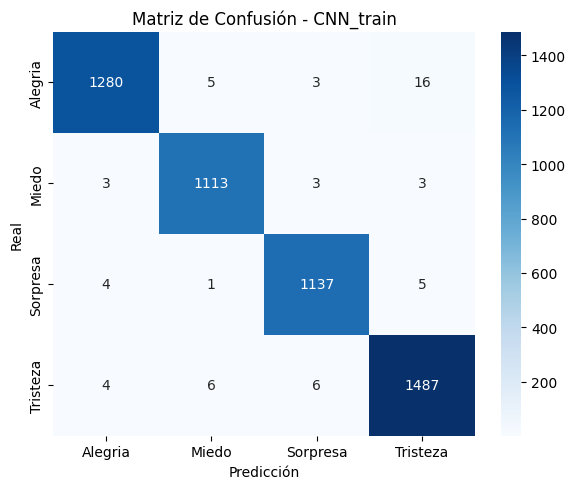

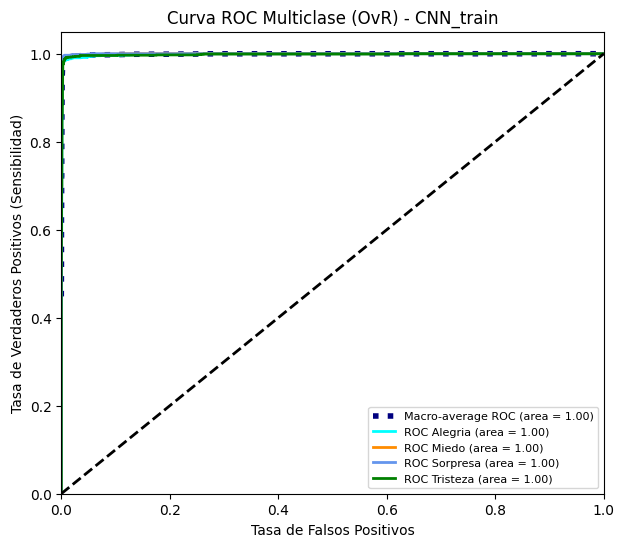

Evaluando CNN en Validación...

 Resultados para CNN_val
Accuracy: 0.5611
Precision (macro): 0.5611
Sensibilidad/Recall (macro): 0.5598
F1-Score (macro): 0.5597

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.50      0.54      0.52       559
       Miedo       0.71      0.70      0.71       481
    Sorpresa       0.46      0.40      0.43       492
    Tristeza       0.57      0.60      0.58       644

    accuracy                           0.56      2176
   macro avg       0.56      0.56      0.56      2176
weighted avg       0.56      0.56      0.56      2176



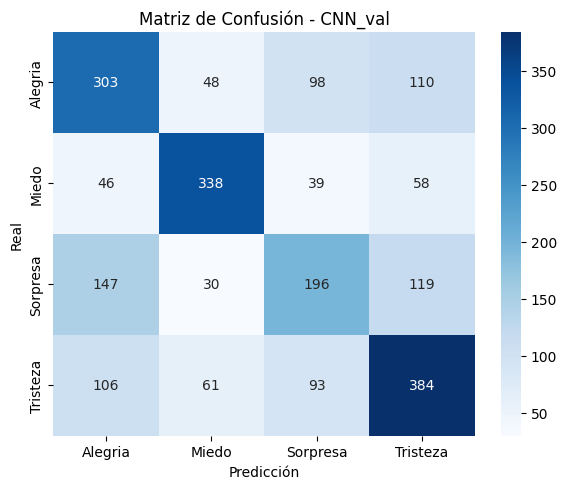

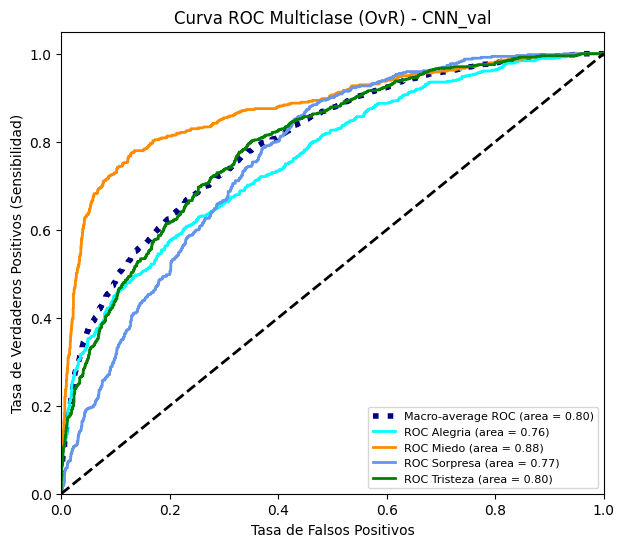

Evaluando CNN en Prueba y Evaluación...

 Resultados para CNN_test
Accuracy: 0.5742
Precision (macro): 0.5784
Sensibilidad/Recall (macro): 0.5733
F1-Score (macro): 0.5753

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.52      0.56      0.54       466
       Miedo       0.72      0.68      0.70       401
    Sorpresa       0.50      0.46      0.48       409
    Tristeza       0.57      0.60      0.59       537

    accuracy                           0.57      1813
   macro avg       0.58      0.57      0.58      1813
weighted avg       0.58      0.57      0.57      1813



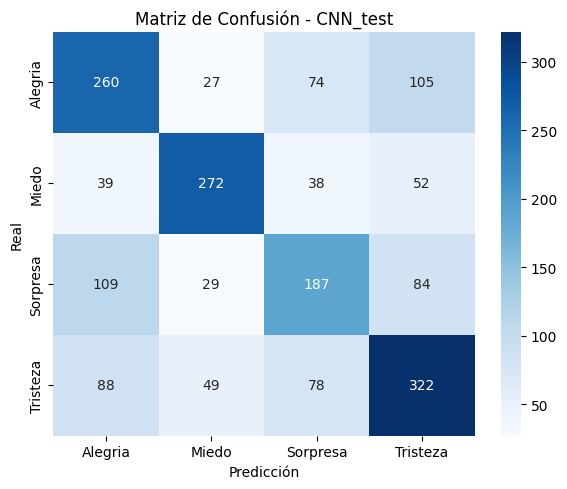

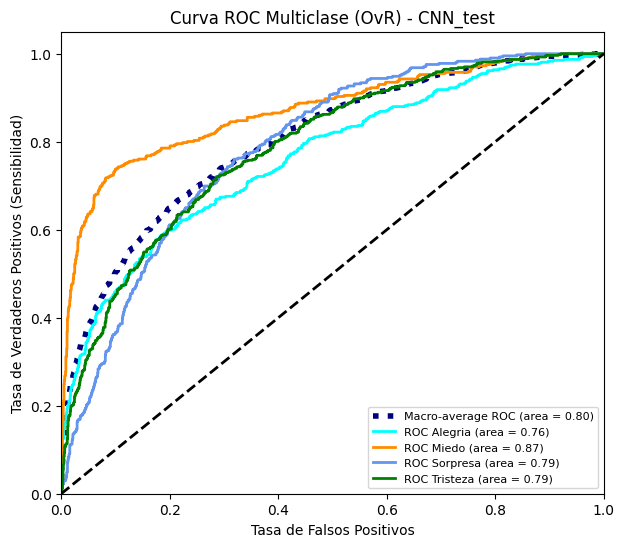


Entrenando modelo LSTM

   Época 1/10 - Perdida Train: 1.3524 - Perdida Val: 1.2887
   Época 2/10 - Perdida Train: 1.1773 - Perdida Val: 1.1089
   Época 3/10 - Perdida Train: 0.9935 - Perdida Val: 1.0562
   Época 4/10 - Perdida Train: 0.8836 - Perdida Val: 1.0472
   Época 5/10 - Perdida Train: 0.7489 - Perdida Val: 1.0843
   Época 6/10 - Perdida Train: 0.6342 - Perdida Val: 1.1158
   Época 7/10 - Perdida Train: 0.5153 - Perdida Val: 1.2453
   [!] Early stopping ejecutado.

Evaluando LSTM en Entrenamiento Efectivo...

 Resultados para LSTM_train
Accuracy: 0.8712
Precision (macro): 0.8754
Sensibilidad/Recall (macro): 0.8694
F1-Score (macro): 0.8711

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.92      0.82      0.87      1304
       Miedo       0.91      0.88      0.89      1122
    Sorpresa       0.84      0.86      0.85      1147
    Tristeza       0.84      0.92      0.88      1503

    accuracy                           0.87  

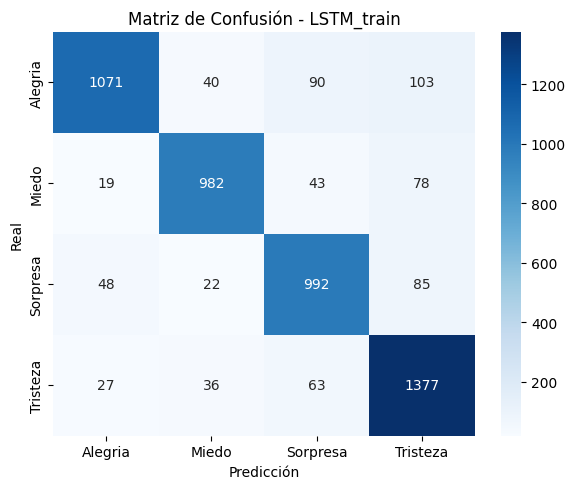

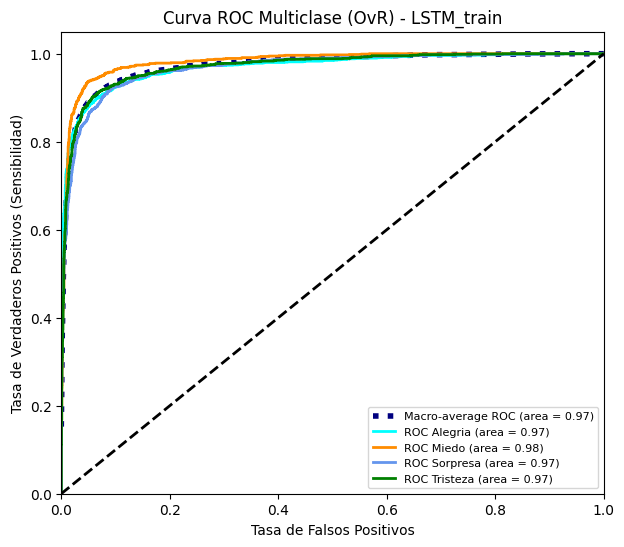

Evaluando LSTM en Validación...

 Resultados para LSTM_val
Accuracy: 0.5584
Precision (macro): 0.5644
Sensibilidad/Recall (macro): 0.5550
F1-Score (macro): 0.5576

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.55      0.48      0.52       559
       Miedo       0.72      0.67      0.69       481
    Sorpresa       0.44      0.42      0.43       492
    Tristeza       0.54      0.64      0.58       644

    accuracy                           0.56      2176
   macro avg       0.56      0.55      0.56      2176
weighted avg       0.56      0.56      0.56      2176



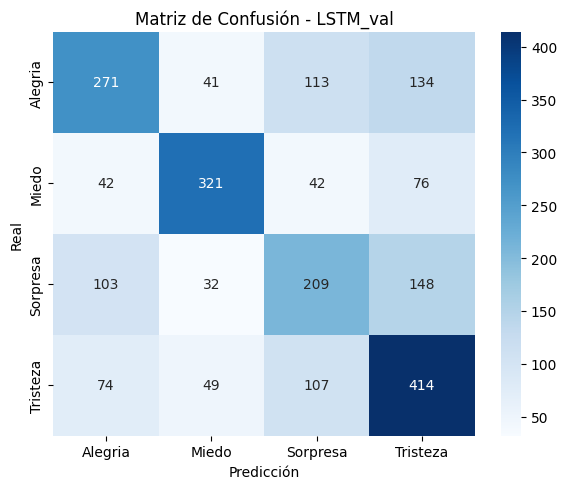

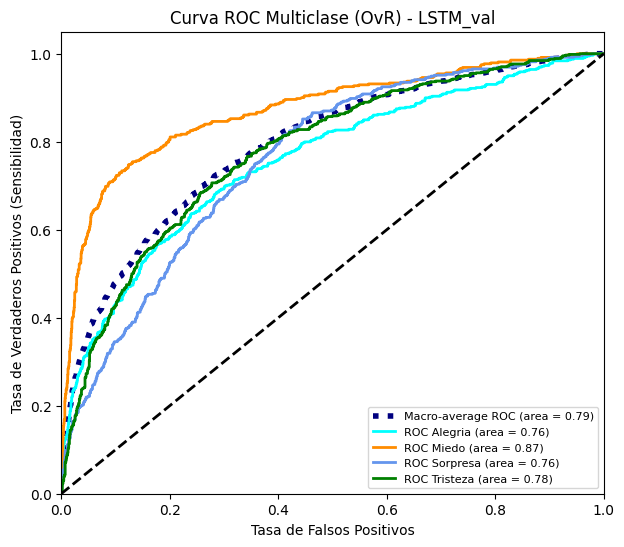

Evaluando LSTM en Prueba y Evaluación...

 Resultados para LSTM_test
Accuracy: 0.5593
Precision (macro): 0.5714
Sensibilidad/Recall (macro): 0.5547
F1-Score (macro): 0.5581

Reporte de Clasificación:
              precision    recall  f1-score   support

     Alegria       0.58      0.45      0.50       466
       Miedo       0.73      0.64      0.68       401
    Sorpresa       0.46      0.45      0.46       409
    Tristeza       0.52      0.67      0.59       537

    accuracy                           0.56      1813
   macro avg       0.57      0.55      0.56      1813
weighted avg       0.57      0.56      0.56      1813



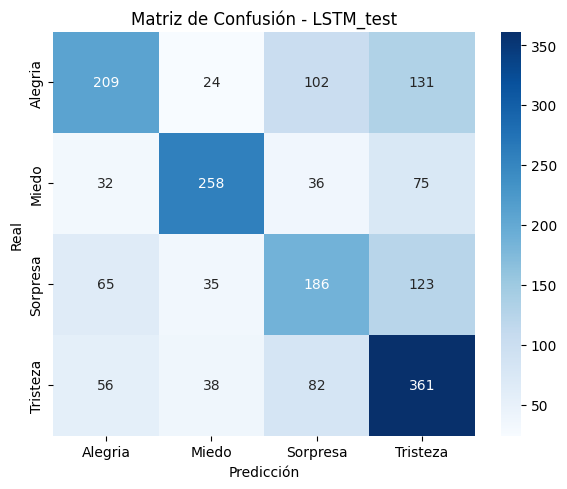

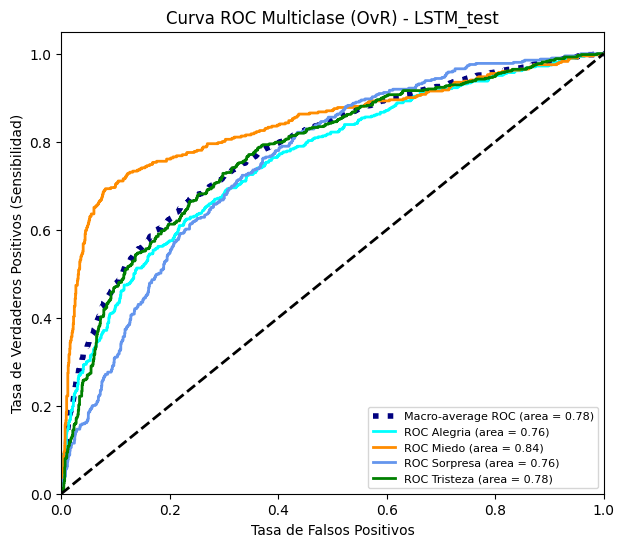


Reporte guardado en: /content/resultados_nn/reporte_nn.md


In [ ]:
# Inicializar el archivo de reporte
archivo_reporte = os.path.join(RESULTADOS_DIR, 'reporte_redes_neuronales.md')
with open(archivo_reporte, 'w', encoding='utf-8') as f:
    f.write("# Reporte de evaluación - Redes Neuronales\n\n")
    f.write("Resultados de métricas de rendimiento para los modelos CNN y LSTM.\n\n")

# CNN
print("Entrenando modelo CNN\n")
model_cnn = CNNModel(vocab_size, EMBEDDING_DIM, num_classes).to(device)
model_cnn = train_model(model_cnn, train_loader, val_loader, device)

with open(archivo_reporte, 'a', encoding='utf-8') as f:
    f.write("---\n\n## CNN\n\n")

print("\nEvaluando CNN en Entrenamiento Efectivo...")
evaluate_and_plot(model_cnn, 'CNN_train', train_loader, device, le, archivo_reporte, titulo_seccion="Resultados en Entrenamiento Efectivo (~56%)")

print("Evaluando CNN en Validación...")
evaluate_and_plot(model_cnn, 'CNN_val', val_loader, device, le, archivo_reporte, titulo_seccion="Resultados en Validación (~24%)")

print("Evaluando CNN en Prueba y Evaluación...")
evaluate_and_plot(model_cnn, 'CNN_test', test_loader, device, le, archivo_reporte, titulo_seccion="Resultados en Prueba y Evaluación (20%)")

# LSTM 
print("\nEntrenando modelo LSTM\n")
model_lstm = LSTMModel(vocab_size, EMBEDDING_DIM, num_classes).to(device)
model_lstm = train_model(model_lstm, train_loader, val_loader, device)

with open(archivo_reporte, 'a', encoding='utf-8') as f:
    f.write("---\n\n## LSTM\n\n")

print("\nEvaluando LSTM en Entrenamiento Efectivo...")
evaluate_and_plot(model_lstm, 'LSTM_train', train_loader, device, le, archivo_reporte,titulo_seccion="Resultados en Entrenamiento Efectivo (~56%)")


print("Evaluando LSTM en Validación...")
evaluate_and_plot(model_lstm, 'LSTM_val', val_loader, device, le, archivo_reporte,
                  titulo_seccion="Resultados en Validación (~24%)")

print("Evaluando LSTM en Prueba y Evaluación...")
evaluate_and_plot(model_lstm, 'LSTM_test', test_loader, device, le, archivo_reporte,
                  titulo_seccion="Resultados en Prueba y Evaluación (20%)")

print(f"\nReporte guardado en: {archivo_reporte}")
